In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. 数据加载和预处理
data = pd.read_csv('life_expectancy_dataset.csv', sep=';', decimal=',')

# 只保留所需列，这里假设你关心女性寿命
data = data[['country_name', 'region', 'year', 'life_expectancy_women']]
data['year'] = pd.to_datetime(data['year'], format='%Y')

# 获取所有大洲列表
continents = data['region'].unique()

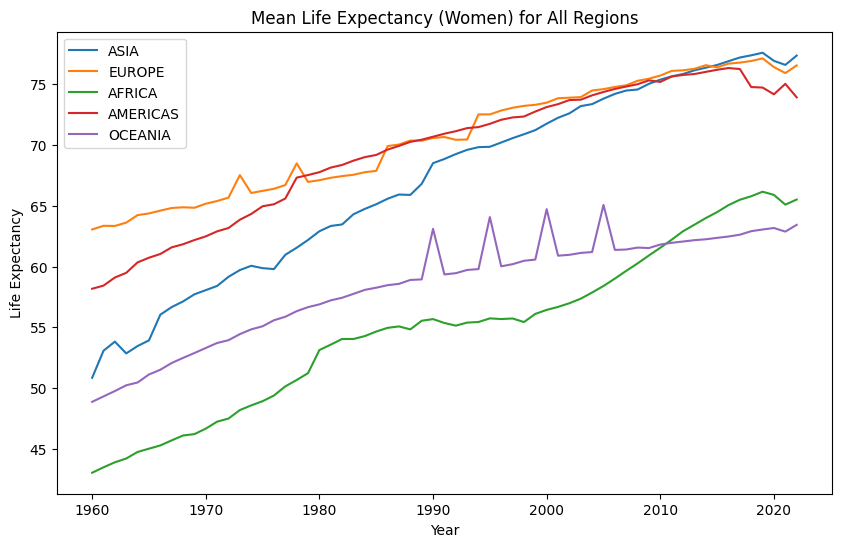

In [2]:
# ============ 1) 原始趋势对比：多条线在同一个图 ============
plt.figure(figsize=(10, 6))

for cont in continents:
    df = data[data['region'] == cont].sort_values('year')
    # 同一年份多个国家，取平均
    df_grouped = df.groupby('year')['life_expectancy_women'].mean()
    plt.plot(df_grouped.index, df_grouped.values, label=cont)

plt.title("Mean Life Expectancy (Women) for All Regions")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.show()

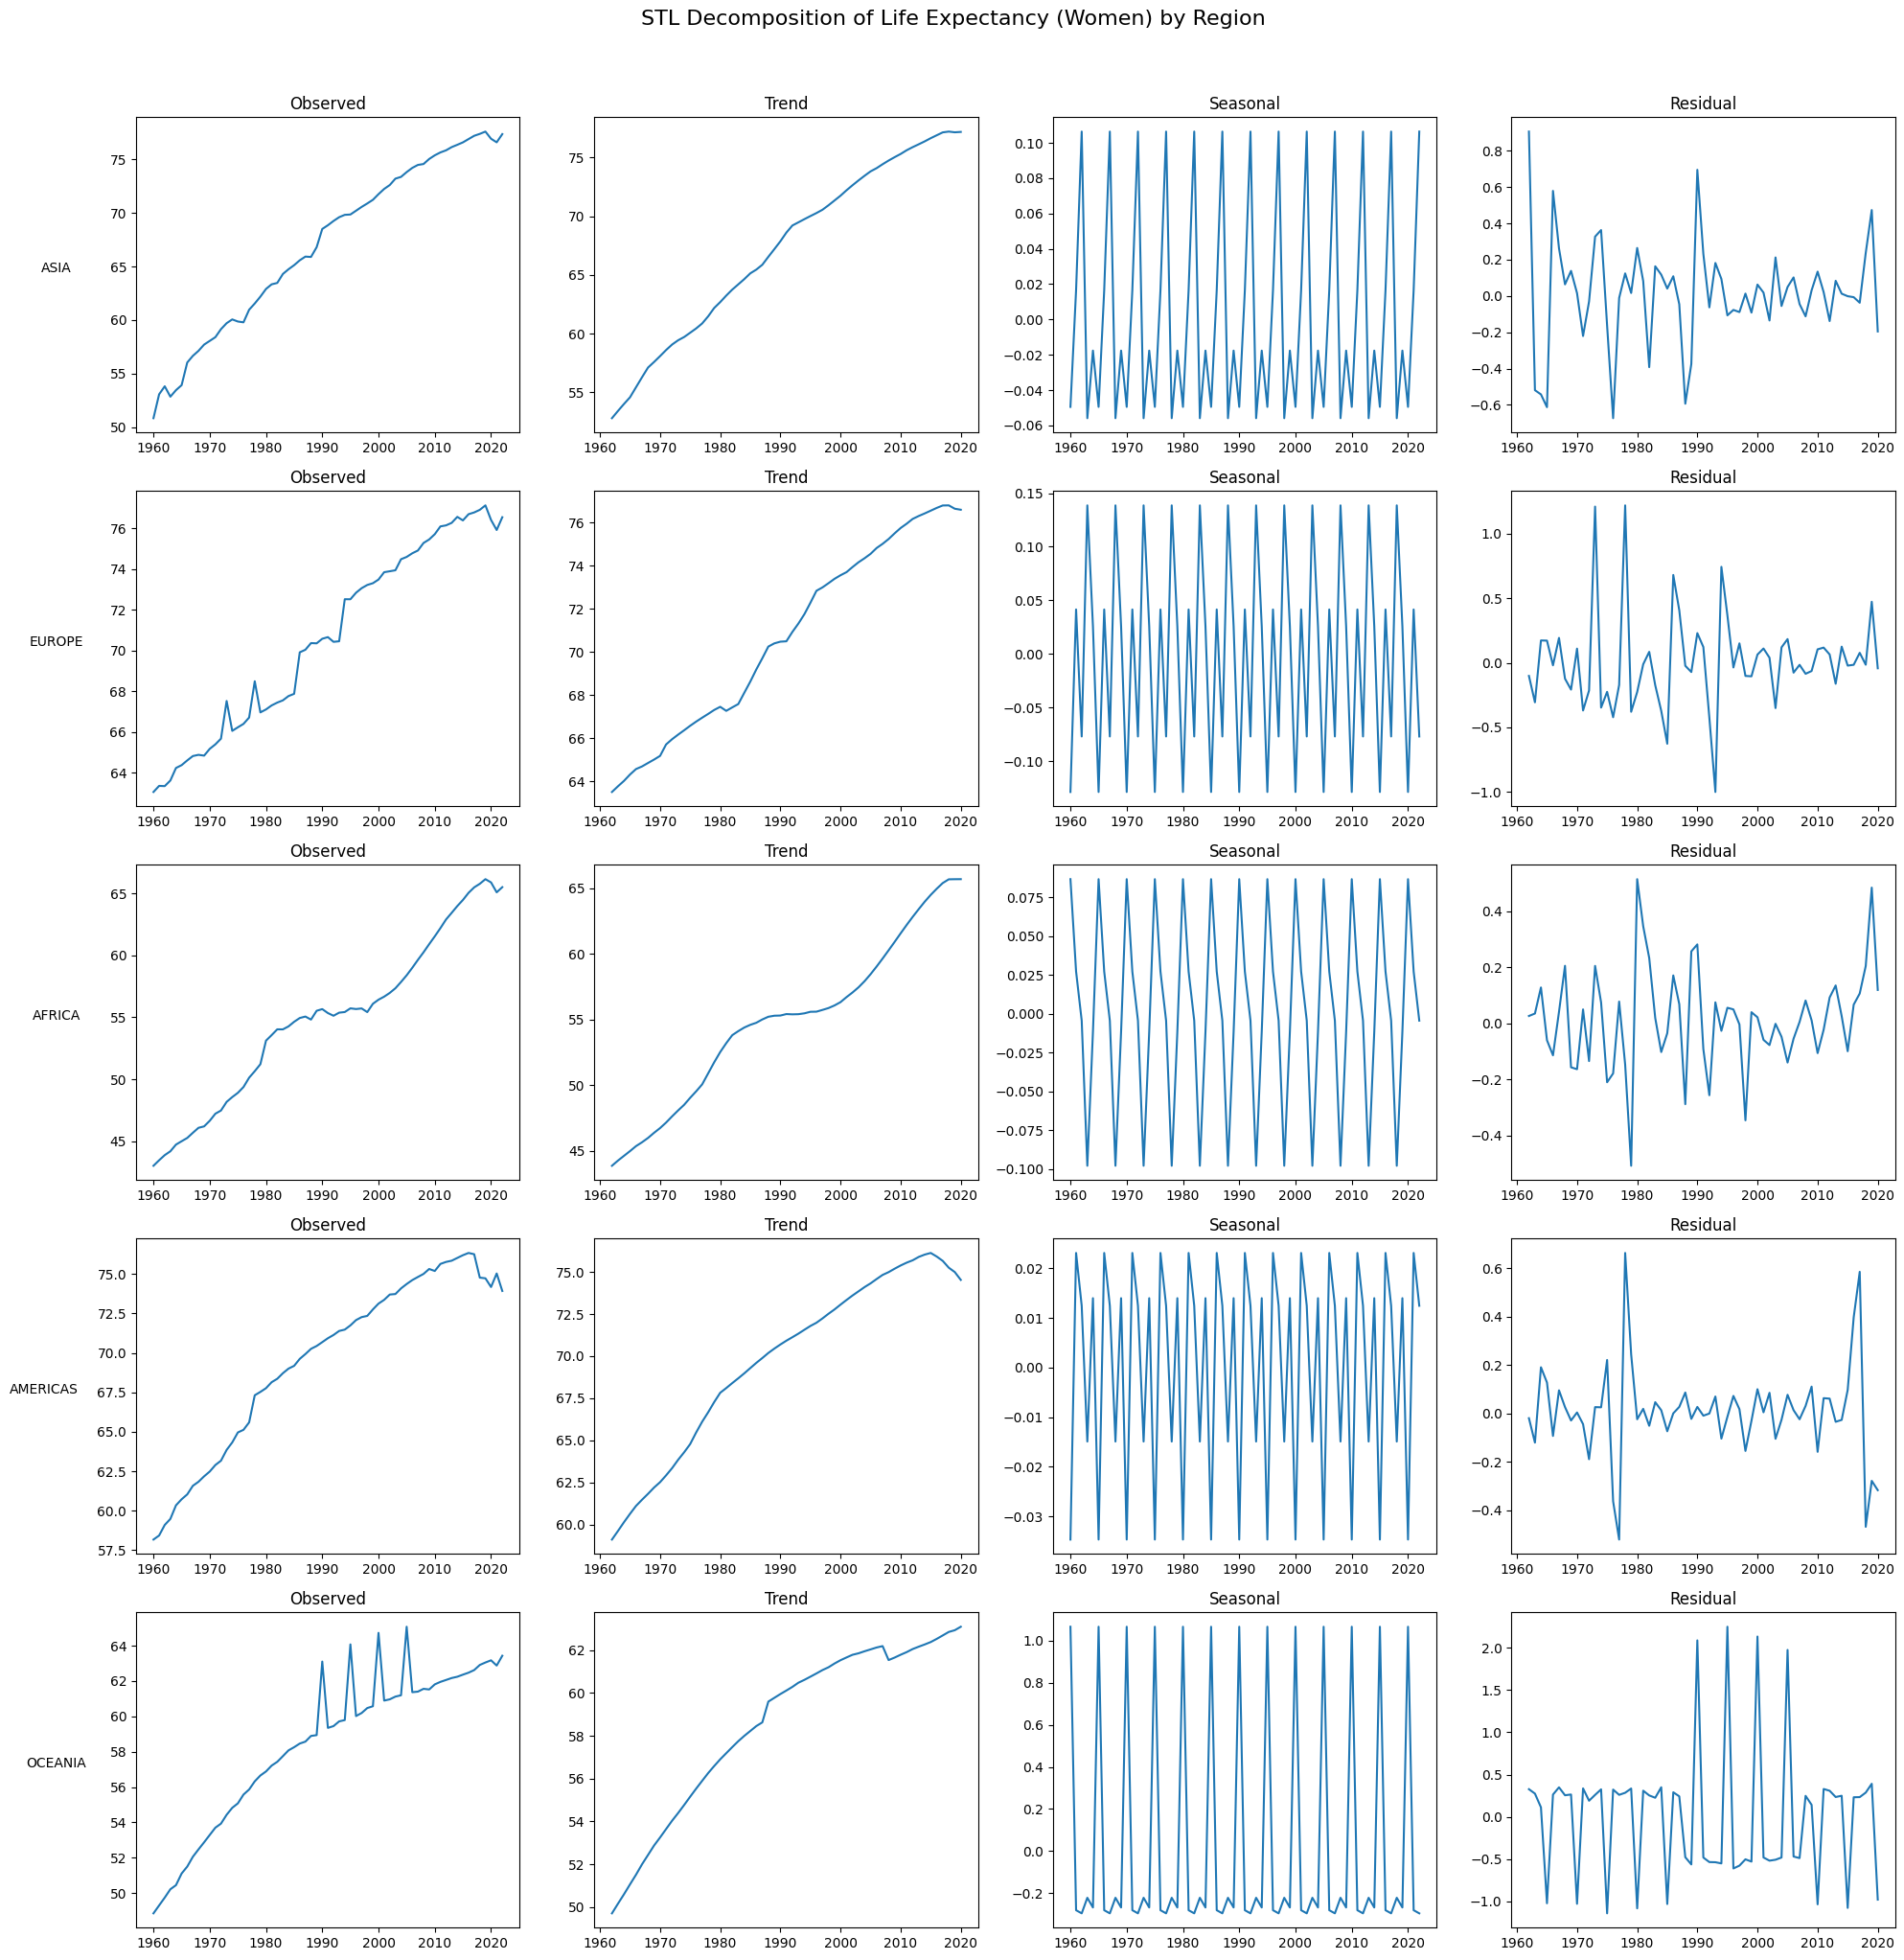

In [3]:
# ============ 2) STL 分解：多个大洲放在同一张大图的不同子图里 ============ 
#    每个大洲一个小 4-分图(Observed/Trend/Seasonal/Residual)
fig, axes = plt.subplots(nrows=len(continents), ncols=4, 
                         figsize=(20, 4 * len(continents)), 
                         sharex=False)

for i, cont in enumerate(continents):
    df = data[data['region'] == cont].sort_values('year')
    df_grouped = df.groupby('year')['life_expectancy_women'].mean()
    
    # 注意 period 需要结合你的数据实际间隔，这里示例设为 5
    decomposition = seasonal_decompose(df_grouped, model='additive', period=5)
    
    # 逐列画图：Observed / Trend / Seasonal / Resid
    axes[i, 0].plot(decomposition.observed)
    axes[i, 0].set_ylabel(cont, rotation=0, labelpad=40)  # 在左侧标注大洲
    axes[i, 0].set_title("Observed")

    axes[i, 1].plot(decomposition.trend)
    axes[i, 1].set_title("Trend")

    axes[i, 2].plot(decomposition.seasonal)
    axes[i, 2].set_title("Seasonal")

    axes[i, 3].plot(decomposition.resid)
    axes[i, 3].set_title("Residual")

plt.suptitle("STL Decomposition of Life Expectancy (Women) by Region", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()



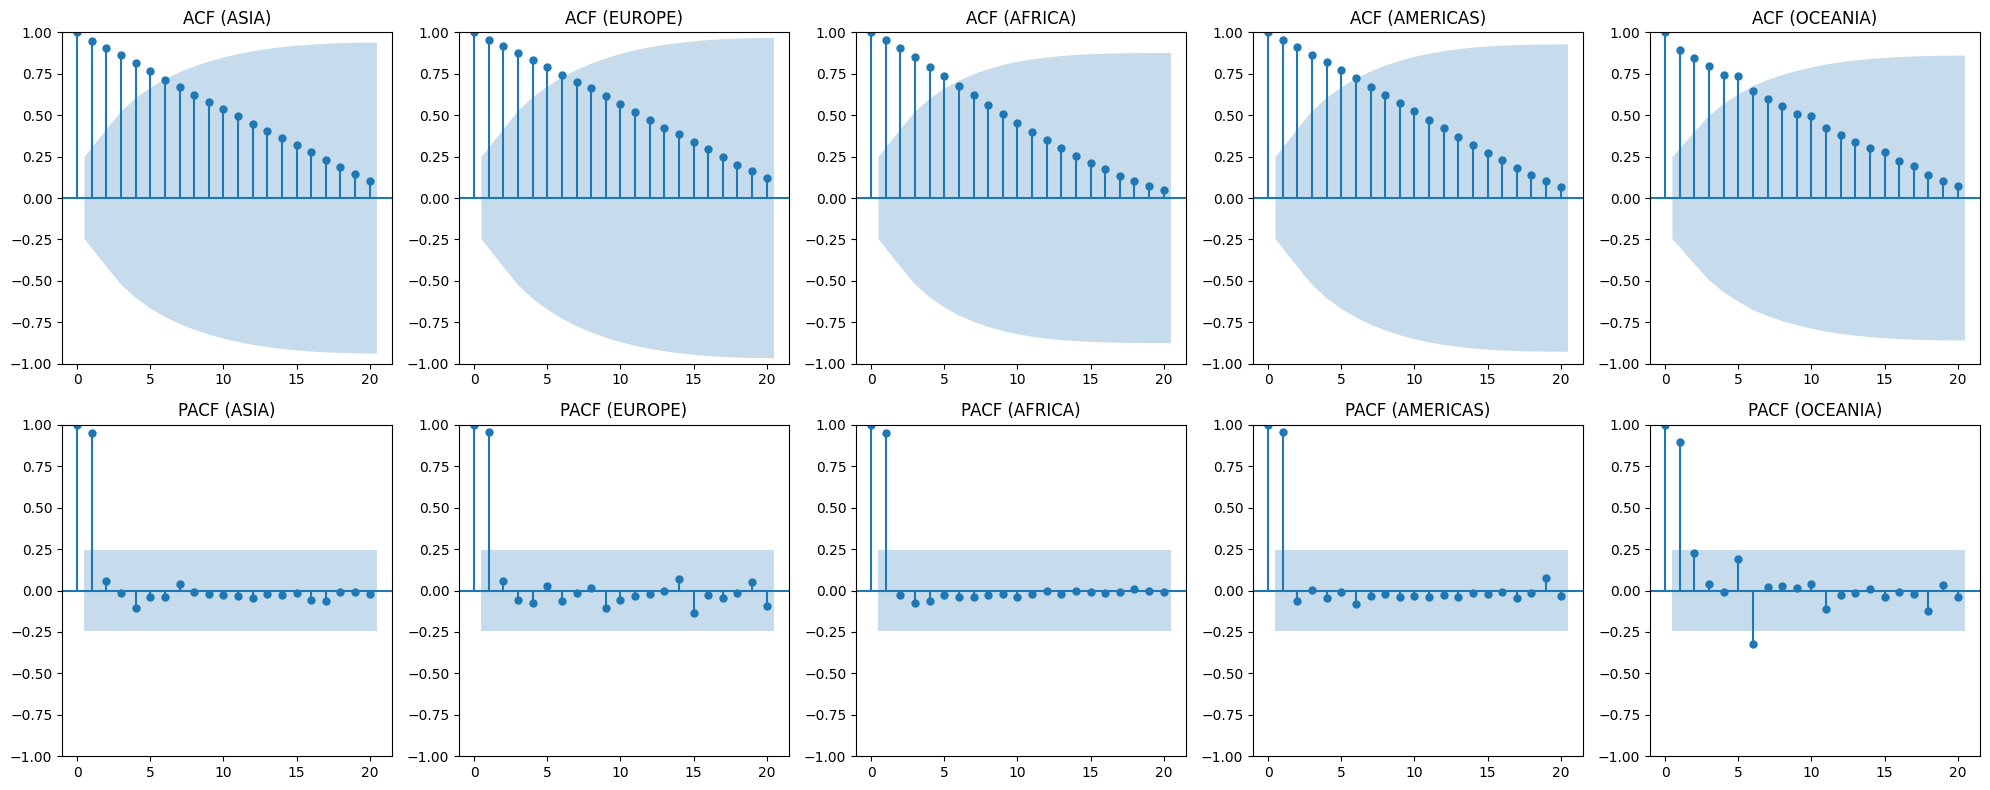

In [4]:
# ============ 3) ACF & PACF：多个大洲分子图对比 ============
#    ACF 和 PACF 一般一次只能画一条序列，所以用子图对比
fig, axes = plt.subplots(nrows=2, ncols=len(continents),
                         figsize=(4*len(continents), 8))
# 上一行 2 表示两行(一行ACF,一行PACF)，列数 = 大洲数

for i, cont in enumerate(continents):
    df = data[data['region'] == cont].sort_values('year')
    df_grouped = df.groupby('year')['life_expectancy_women'].mean()

    # ACF 放在第0行，第 i 列
    plot_acf(df_grouped, lags=20, ax=axes[0, i], title=f"ACF ({cont})")
    # PACF 放在第1行，第 i 列
    plot_pacf(df_grouped, lags=20, ax=axes[1, i], title=f"PACF ({cont})")

plt.tight_layout()
plt.show()

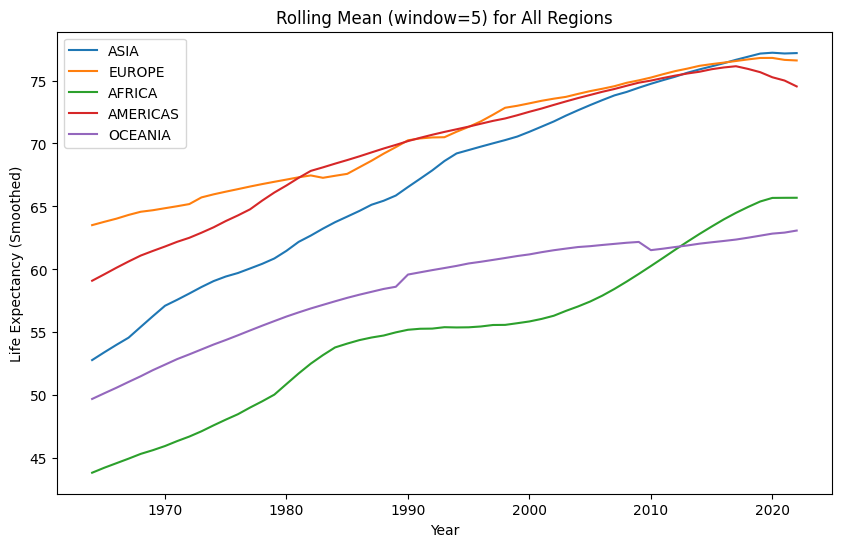

In [5]:
# ============ 4) 滑动平均对比：多条线同图 ============
window = 5  # 移动平均窗口大小
plt.figure(figsize=(10, 6))

for cont in continents:
    df = data[data['region'] == cont].sort_values('year')
    df_grouped = df.groupby('year')['life_expectancy_women'].mean()
    rolling_mean = df_grouped.rolling(window=window).mean()
    plt.plot(rolling_mean.index, rolling_mean.values, label=cont)

plt.title(f"Rolling Mean (window={window}) for All Regions")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Smoothed)")
plt.legend()
plt.show()



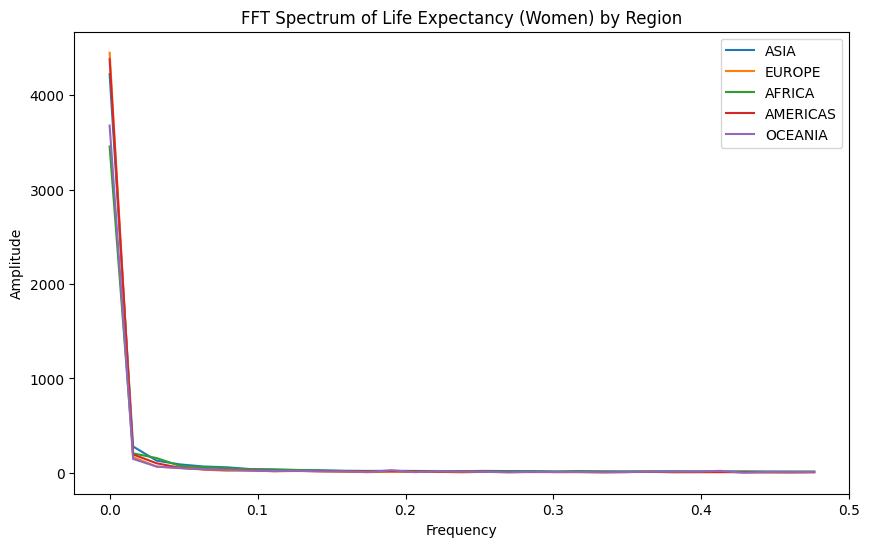

In [6]:
# ============ 5) 频域分析（FFT）：多条线同图 ============
plt.figure(figsize=(10, 6))

for cont in continents:
    df = data[data['region'] == cont].sort_values('year')
    df_grouped = df.groupby('year')['life_expectancy_women'].mean()

    signal = df_grouped.values
    n = len(signal)
    fft_spectrum = np.fft.fft(signal)
    freq = np.fft.fftfreq(n)  # 频率刻度

    # 只画正频率部分
    plt.plot(freq[:n//2], np.abs(fft_spectrum)[:n//2], label=cont)

plt.title("FFT Spectrum of Life Expectancy (Women) by Region")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.legend()
plt.show()